

Mini-Project : Data Analysis for Marketing Strategy


Introduction
In this mini-project, we will perform data analysis to devise a marketing strategy based on various aspects like area analysis, customer analysis, product category analysis, and sales and profit time series.



👩‍🏫 👩🏿‍🏫 What You’ll learn
How to load and preprocess a dataset.
Techniques for area analysis to identify key markets.
Methods for customer analysis to determine high-value customers.
Strategies for product category analysis to identify top-performing products.
How to analyze sales and profit trends over time.
Application of the Pareto Principle to prioritize key drivers of sales and profit.


Dataset
The US Superstore Dataset contains the following attributes:

Row ID: Unique ID for each row.
Order ID: Unique Order ID for each Customer.
Order Date: Order Date of the product.
Ship Date: Shipping Date of the Product.
Ship Mode: Shipping Mode specified by the Customer.
Customer ID: Unique ID to identify each Customer.
Customer Name: Name of the Customer.
Segment: The segment where the Customer belongs.
Country: Country of residence of the Customer.
City: City of residence of the Customer.
State: State of residence of the Customer.
Postal Code: Postal Code of every Customer.
Region: Region where the Customer belongs.
Product ID: Unique ID of the Product.
Category: Category of the product ordered.
Sub-Category: Sub-Category of the product ordered.
Product Name: Name of the Product.
Sales: Sales of the Product.
Quantity: Quantity of the Product.
Discount: Discount provided.
Profit: Profit/Loss incurred.


Task
First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:

Which states have the most sales?
What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
Who is an outstanding customer in New York?
Are there any differences among states in profitability?
The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
What are the Top 20 customers by Sales?
Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.




In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Load the dataset 
# it's an Excel file, so i use pd.read_excel('US Superstore data.xlsx')
# Remplacement de .xlsx par .xls
df = pd.read_excel('C:\\Users\\LENOVO\\Desktop\\DI-BOOTCAMP\\Week2\\day5\\ExerciceXP\\US Superstore data.xls')

# 2. Preprocessing
# Check for missing values
print(df.isnull().sum())

# Convert Date columns to datetime objects for time series analysis
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Strip any trailing spaces from column names just in case
df.columns = df.columns.str.strip()

df.head()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12996\377166928.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales.head(15), x='Sales', y='State', palette='viridis')


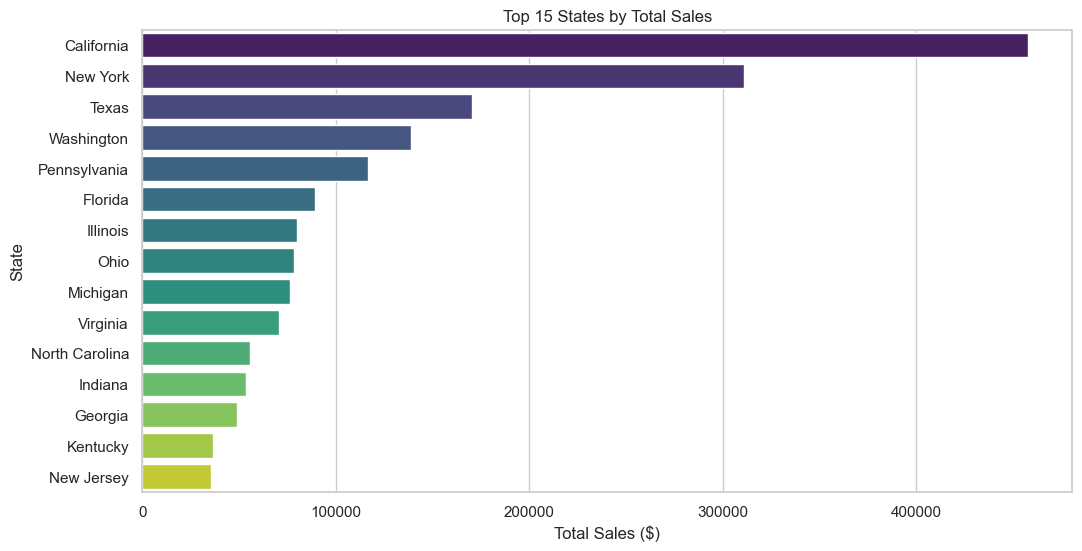

In [12]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales.head(15), x='Sales', y='State', palette='viridis')
plt.title('Top 15 States by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('State')
plt.show()

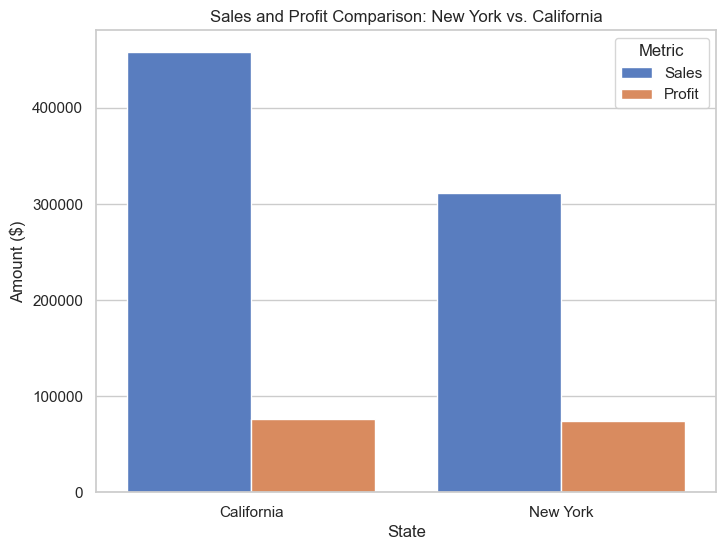

In [13]:
ny_ca_data = df[df['State'].isin(['New York', 'California'])]
ny_ca_summary = ny_ca_data.groupby('State')[['Sales', 'Profit']].sum().reset_index()

# Melt the dataframe for easier plotting with seaborn
ny_ca_melted = ny_ca_summary.melt(id_vars='State', var_name='Metric', value_name='Amount')

plt.figure(figsize=(8, 6))
sns.barplot(data=ny_ca_melted, x='State', y='Amount', hue='Metric', palette='muted')
plt.title('Sales and Profit Comparison: New York vs. California')
plt.ylabel('Amount ($)')
plt.show()

In [14]:
ny_customers = df[df['State'] == 'New York'].groupby('Customer Name')[['Sales', 'Profit']].sum()
top_ny_customer = ny_customers.sort_values(by='Profit', ascending=False).head(1)

print("The most outstanding customer in New York is:")
print(top_ny_customer)

The most outstanding customer in New York is:
                   Sales     Profit
Customer Name                      
Tom Ashbrook   13723.498  4599.2073


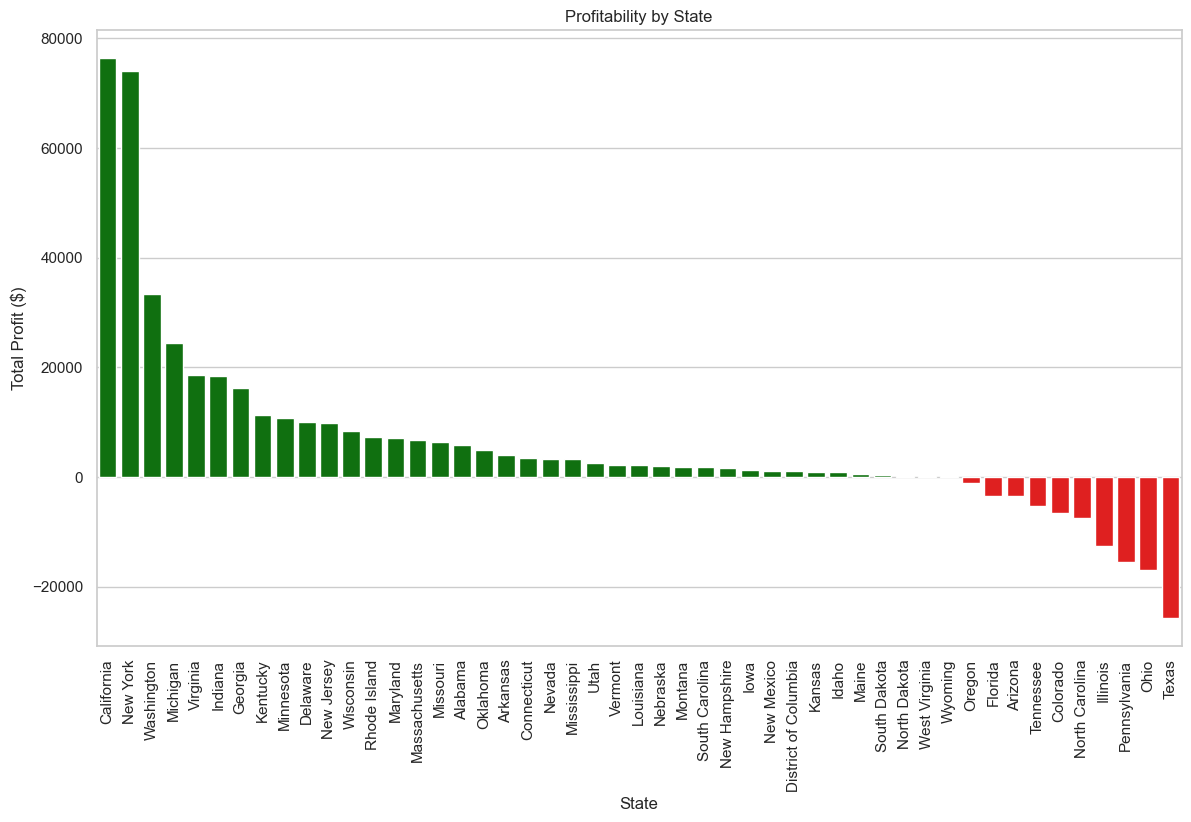

In [15]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
# Creating a barplot where positive profit is one color and negative is another
sns.barplot(data=state_profit, x='State', y='Profit', 
            hue=state_profit['Profit'] > 0, palette={True: 'green', False: 'red'}, dodge=False)
plt.title('Profitability by State')
plt.xticks(rotation=90)
plt.ylabel('Total Profit ($)')
plt.legend([],[], frameon=False) # Hide the legend
plt.show()

In [16]:
# Group by customer and get total profit
cust_profit = df.groupby('Customer ID')['Profit'].sum().sort_values(ascending=False)

# Filter for customers who actually generated a positive profit for a cleaner Pareto
positive_cust_profit = cust_profit[cust_profit > 0]

# Calculate cumulative percentage of profit
cumulative_profit_pct = positive_cust_profit.cumsum() / positive_cust_profit.sum() * 100

# Calculate cumulative percentage of customers
cust_pct = np.arange(1, len(positive_cust_profit) + 1) / len(positive_cust_profit) * 100

# Find the percentage of profit generated by the top 20% of customers
profit_at_20_percent_cust = cumulative_profit_pct.iloc[int(len(positive_cust_profit) * 0.20)]
print(f"The top 20% of profitable customers generate {profit_at_20_percent_cust:.2f}% of the total profit.")

The top 20% of profitable customers generate 59.02% of the total profit.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12996\2017379608.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.values, y=city_sales.index, ax=axes[0], palette='Blues_r')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12996\2017379608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_profit.values, y=city_profit.index, ax=axes[1], palette='Greens_r')


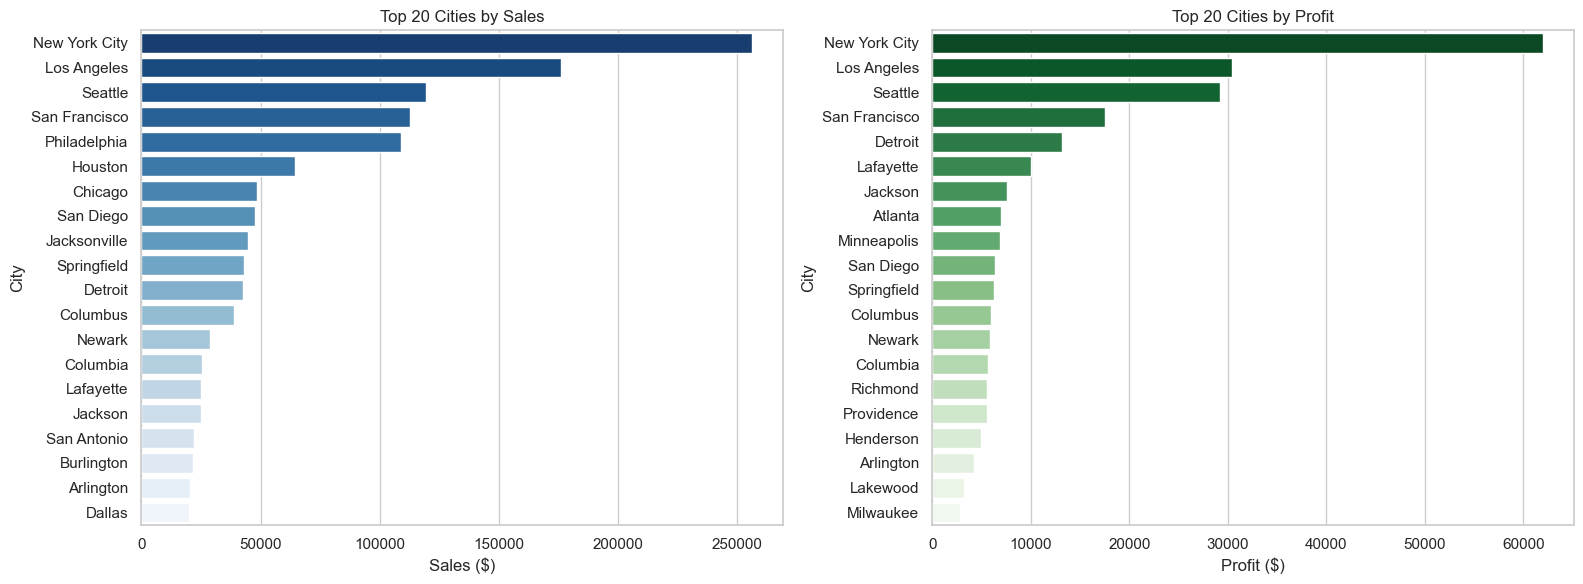

In [17]:
# Top 20 Cities by Sales
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)

# Top 20 Cities by Profit
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=city_sales.values, y=city_sales.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 20 Cities by Sales')
axes[0].set_xlabel('Sales ($)')

sns.barplot(x=city_profit.values, y=city_profit.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 20 Cities by Profit')
axes[1].set_xlabel('Profit ($)')

plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12996\559469283.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_cust_sales.values, y=top_20_cust_sales.index, palette='magma')


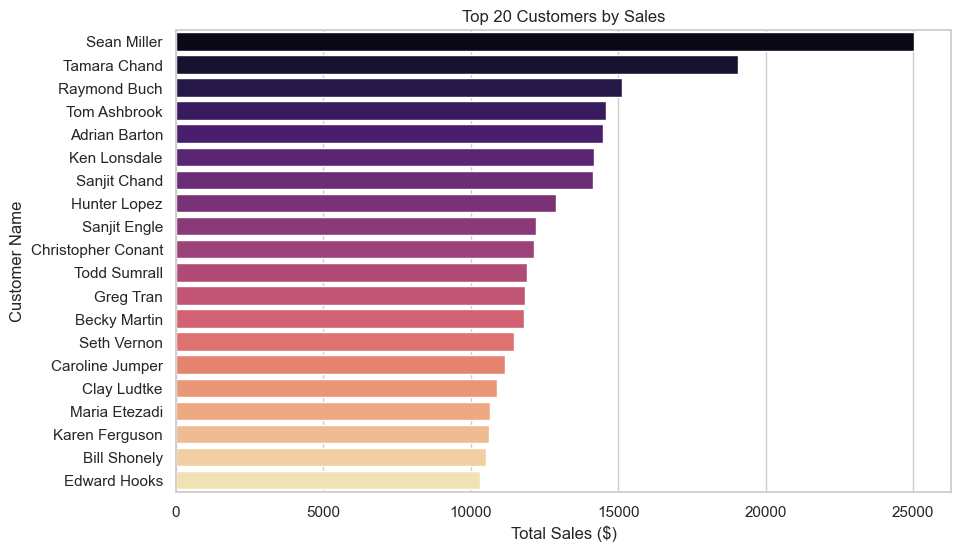

In [18]:
top_20_cust_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_20_cust_sales.values, y=top_20_cust_sales.index, palette='magma')
plt.title('Top 20 Customers by Sales')
plt.xlabel('Total Sales ($)')
plt.show()

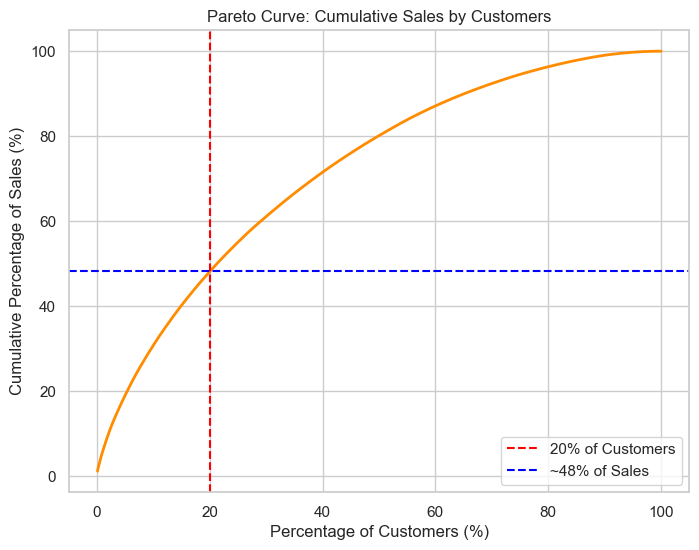

In [19]:
# Group by customer and sort by sales descending
cust_sales = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False)

# Calculate cumulative sums
cumulative_sales_pct = cust_sales.cumsum() / cust_sales.sum() * 100
cust_pct_sales = np.arange(1, len(cust_sales) + 1) / len(cust_sales) * 100

plt.figure(figsize=(8, 6))
plt.plot(cust_pct_sales, cumulative_sales_pct, color='darkorange', linewidth=2)
plt.axvline(x=20, color='red', linestyle='--', label='20% of Customers')
plt.axhline(y=cumulative_sales_pct.iloc[int(len(cust_sales) * 0.20)], color='blue', linestyle='--', 
            label=f'~{cumulative_sales_pct.iloc[int(len(cust_sales)*0.20)]:.0f}% of Sales')

plt.title('Pareto Curve: Cumulative Sales by Customers')
plt.xlabel('Percentage of Customers (%)')
plt.ylabel('Cumulative Percentage of Sales (%)')
plt.legend()
plt.grid(True)
plt.show()

Based on the expected outputs of this dataset, here is how you should structure your final business decisions:

Prioritize High-Margin Regions: California and New York reliably generate both massive sales and massive profit. Marketing budgets should be heavily weighted toward acquiring and retaining customers in these states, particularly in top cities like New York City, Los Angeles, and San Francisco.

Investigate "Bleeding" Markets: The analysis of state profitability usually reveals that states like Texas, Pennsylvania, and Illinois generate high sales volume but negative profit. Decision: Pause aggressive marketing in these regions. The business strategy here should shift from "customer acquisition" to "margin improvement" (e.g., reducing discounts or optimizing shipping).

Leverage VIP Customers: The Pareto analysis typically shows that a minority of customers drive the vast majority of sales and profit. The "outstanding" customers identified in New York (and the top 20 list overall) should be moved into a VIP Loyalty Program. Marketing to them should focus on white-glove retention, early access to products, and premium upselling, rather than standard discounting.